In [16]:
import matplotlib.pyplot as plt
import io
import requests
import xarray as xr

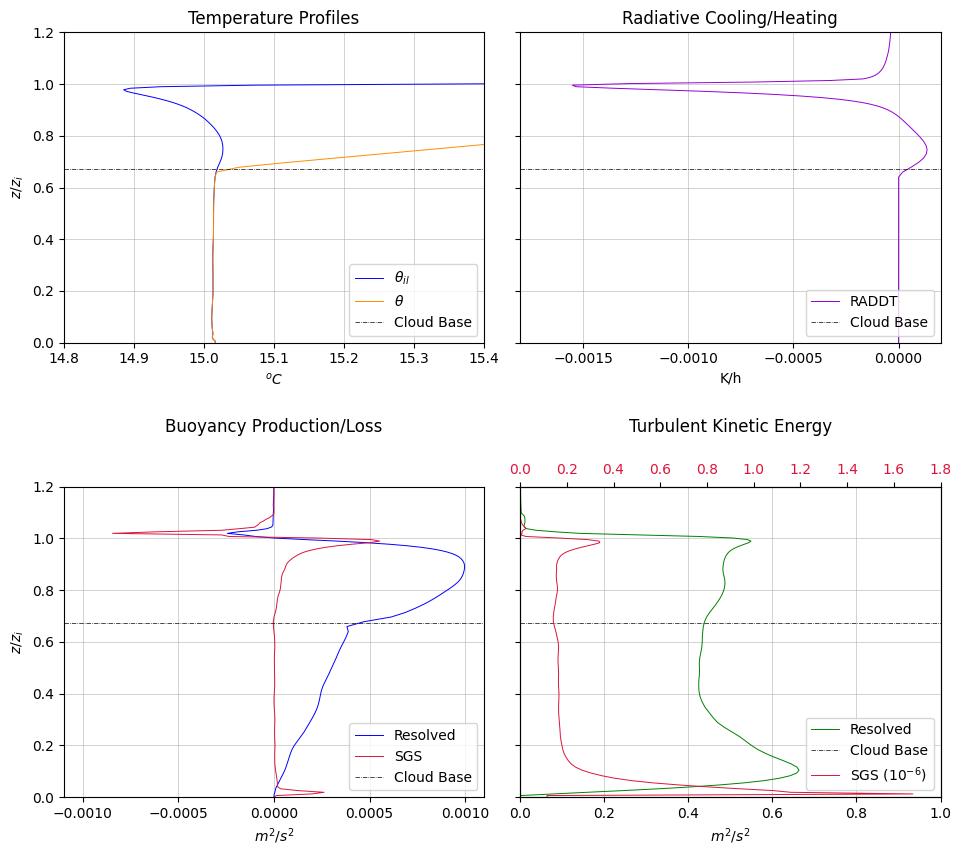

In [20]:
# --- Cloud base (last time step) ---
zi=833.5
c_base=560/zi

# --- Buoyancy/TKE data ---
url4="https://raw.githubusercontent.com/ChrisPhys97/Bachelor-Thesis/refs/heads/main/data/Buoyancy_TKE_data.nc"
response=requests.get(url4)
data=response.content
bf=xr.open_dataset(io.BytesIO(data),engine="h5netcdf")

fig,ax=plt.subplots(2,2,figsize=(9.5,8.5),constrained_layout={'hspace': 0.07, 'h_pad': 0.07})
ax[0,0].plot(bf.PTIL.values-273.15,bf.z.values/zi,linewidth=0.7,color="b",label=r"$\theta_{il}$")
ax[0,0].plot(bf.PT.values-273.15,bf.z.values/zi,color="darkorange",linewidth=0.7,label=r"$\theta$")
ax[0,1].plot(bf.RADDT.values,bf.z.values/zi,color="darkviolet",linewidth=0.7,label="RADDT")
ax[0,1].set_yticklabels([])
ax[1,0].plot(bf.BFRES.values,bf.z.values/zi,linewidth=0.7,color="b",label="Resolved")
ax[1,0].plot(bf.BFSGS.values,bf.z.values/zi,linewidth=0.7,color="crimson",label="SGS")
ax[1,1].plot(bf.TKERES.values, bf.z.values/zi, linewidth=0.7, color="g", label="Resolved")
ax[1,1].set_yticklabels([])

ax_twin = ax[1,1].twiny()
ax_twin.plot(bf.TKESGS.values/1e-6, bf.z.values/zi, linewidth=0.7, color="crimson", label="SGS $(10^{-6})$")
ax_twin.tick_params(axis='x', labelcolor='crimson')
xlabels=["${}^oC$","K/h","$m^2/s^2$","$m^2/s^2$"]
subplot_titles = ["Temperature Profiles","Radiative Cooling/Heating","Buoyancy Production/Loss","Turbulent Kinetic Energy"]
i=0
for a_single_ax in ax.flat:
  a_single_ax.set_ylim([0,1.2])
  a_single_ax.set_xlabel(xlabels[i])
  if i >= 2: a_single_ax.set_title(subplot_titles[i], y=1.15) # Keep higher y for top row

  else: a_single_ax.set_title(subplot_titles[i])
  a_single_ax.grid(True,linewidth=0.5,alpha=0.8)
  a_single_ax.axhline(y=c_base,linewidth=0.5,color="k",label="Cloud Base",linestyle="-.")

  if a_single_ax != ax[1,1]: a_single_ax.legend(loc="lower right")
  i+=1
handles1, labels1 = ax[1,1].get_legend_handles_labels()
handles2, labels2 = ax_twin.get_legend_handles_labels()
ax_twin.set_xlim([0,1.8])
ax[1,1].legend(handles1 + handles2, labels1 + labels2, loc='lower right')
ax[1,1].set_xlim([0,1])
ax[0,0].set_xlim([14.8,15.4])
ax[0,1].set_xlim([-0.0018,0.0002])
ax[0,1].set_xticks([-0.0015,-0.001, -0.0005, 0])
ax[1,0].set_xlim([-0.0011,0.0011])
ax[1,0].set_xticks([-0.001, -0.0005, 0, 0.0005, 0.001])
ax[0,0].set_ylabel("$z/z_i$")
ax[1,0].set_ylabel("$z/z_i$")
plt.show()

## Results and Discussion

<div style="text-align: justify;
text-justify: inter-word; font-size: 17px;">

The shear-dominant case, exhibits a well mixed boundary layer bellow the cloud base, as it seen at the temperature profiles, while the potential temperature and the ice-liquid potential temperature are identical with zero gradient. However, withing the cloud layer the potentail temperature increases more sharply, reflecting the absorbed lathen heat from the phase chane of water vapor. On the other hand the ice-liquid potential temperature accouts for the phase changes and it is the most consevative temperature and thus, the sharp inversion (reaching the temperature of free-atmosphere)appears at ABL top. However, the ice-liquid potential temperature does not take into account heat emission or absorbion from radiation. This fact, is illustrated by the plot of radiative heating/cooling. Near the cloud bease the system exhibits radiative heating while on ABL top there is a strong radiative cooling reflecting it to the ice-liquid potential temperature which has bigger value from the mixed layer, near the cloud base and smaller values near the ABL top. Another fact worth mentining it is the extremly small surface inversion. It seems that a very thin layer above surface it is slightly warmer than the above mixed layer even though SHF and LHF are set to zero.
</div>